# Porównanie odległości od metra

Porównujemy `metro_dist_m` z `dane/warszawa_lokale_metro.csv` z `bdot_wejscie_metro_dist_m` ze zbioru rozszerzonego BDOT10k. **Pierwsza cecha mierzy do punktu stacji, druga do najbliższego eksploatowanego wejścia.** Oba wyniki są odległościami w linii prostej, a nie długością dojścia.

Analiza rozdziela zmianę metryki od zmiany definicji i źródła obiektu. Dodatnia różnica oznacza, że nowa odległość jest większa. Główne statystyki obejmują tylko rekordy z obiema odległościami; osobno pokazujemy wyniki dla unikalnych lokalizacji, by częste transakcje pod tym samym adresem nie dominowały porównania.

Uruchom wszystkie komórki w środowisku z `requirements.txt`, po wykonaniu `bdot10k_wskazniki.ipynb`. Eksporty trafiają do `dane/pochodne_bdot10k/porownanie_metro/` i nie zastępują wcześniejszych danych.

In [1]:
from pathlib import Path
import json, hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT=next(p for p in [Path.cwd(),*Path.cwd().parents] if (p/'dane/warszawa_lokale_metro.csv').exists())
OUT=ROOT/'dane/pochodne_bdot10k/porownanie_metro'
OUT.mkdir(parents=True,exist_ok=True)
OLD=ROOT/'dane/warszawa_lokale_metro.csv'
NEW=ROOT/'dane/pochodne_bdot10k/warszawa_lokale_bdot10k.csv'
STATIONS=ROOT/'dane/interpreter.csv'
old=pd.read_csv(OLD,float_precision='round_trip')
identity=['latitude','longitude','name.1','creation_date','street','amount','size']
new=pd.read_csv(NEW,usecols=['source_row_id',*identity,'bdot_wejscie_metro_dist_m','bdot_poza_warszawa'],float_precision='round_trip')
assert len(old)==len(new)
assert np.array_equal(new.source_row_id,np.arange(len(old)))
pd.testing.assert_frame_equal(old[identity],new[identity])
comparison=new[['source_row_id',*identity,'bdot_poza_warszawa']].copy()
comparison['metro_stare']=old.metro
comparison['stara_odleglosc_m']=old.metro_dist_m
comparison['nowa_odleglosc_m']=new.bdot_wejscie_metro_dist_m
comparison['roznica_m']=comparison.nowa_odleglosc_m-comparison.stara_odleglosc_m
comparison['roznica_bezwzgledna_m']=comparison.roznica_m.abs()
print('Zgodność kolejności i pól identyfikujących: OK.', 'Rekordy:',len(comparison))

Zgodność kolejności i pól identyfikujących: OK. Rekordy: 229727


## 1. Odtworzenie starego algorytmu i rozdzielenie przyczyn

Stary notebook używał przelicznika 111 320 m/stopień, cosinusa szerokości lokalu i zaokrąglenia do metra. Odtwarzamy ten algorytm dla tych samych 38 punktów stacji. Następnie liczymy odległości do **tych samych punktów** Haversine’em, z promieniem Ziemi 6 371 008,8 m, zgodnym z notebookiem BDOT10k.

Rozkład różnicy jest addytywny:

`nowa − stara = (Haversine do stacji − stara) + (nowa − Haversine do stacji)`.

Pierwszy składnik obejmuje zmianę wzoru, zaokrąglenia i ewentualną zmianę najbliższej stacji wskutek metryki. Drugi obejmuje **łącznie definicję obiektu i źródło geometrii** (38 punktów stacji z wcześniejszego eksportu versus 248 eksploatowanych wejść BDOT10k). Nie jest czystym efektem przesunięcia punktu w ramach jednego źródła.

In [2]:
stations=pd.read_csv(STATIONS,sep='|')
stations.columns=stations.columns.str.lstrip('@')
locations=old[['latitude','longitude']].drop_duplicates().reset_index(drop=True)
q=locations.to_numpy(); m=stations[['lat','lon']].to_numpy()
assert len(stations)==38
legacy=(q[:,None,:]-m[None,:,:])*111320
legacy[:,:,1]*=np.cos(np.radians(q[:,None,0]))
legacy_d=np.sqrt((legacy**2).sum(axis=2))
locations['odtworzona_stara_m']=legacy_d.min(axis=1).round(0)
locations['odtworzona_stacja']=stations.name.to_numpy()[legacy_d.argmin(axis=1)]

def haversine_m(a,b):
    a,b=np.radians(a),np.radians(b)
    d=b-a
    h=np.sin(d[...,0]/2)**2+np.cos(a[...,0])*np.cos(b[...,0])*np.sin(d[...,1]/2)**2
    return 2*6371008.8*np.arcsin(np.sqrt(np.clip(h,0,1)))

station_haversine=haversine_m(q[:,None,:],m[None,:,:])
locations['haversine_do_stacji_m']=station_haversine.min(axis=1)
locations['stacja_haversine']=stations.name.to_numpy()[station_haversine.argmin(axis=1)]
comparison=comparison.merge(locations,on=['latitude','longitude'],how='left',validate='many_to_one',sort=False)
assert np.array_equal(comparison.source_row_id,np.arange(len(old)))
assert np.array_equal(comparison.odtworzona_stara_m,comparison.stara_odleglosc_m)
assert (comparison.odtworzona_stacja==comparison.metro_stare).all()
comparison['efekt_metryki_m']=comparison.haversine_do_stacji_m-comparison.stara_odleglosc_m
comparison['efekt_definicji_i_zrodla_m']=comparison.nowa_odleglosc_m-comparison.haversine_do_stacji_m
assert np.allclose(comparison.roznica_m,comparison.efekt_metryki_m+comparison.efekt_definicji_i_zrodla_m,equal_nan=True)
print('Dokładne odtworzenie wszystkich starych odległości i przypisań stacji: OK')
print('Lokalizacje ze zmianą najbliższej stacji tylko przez metrykę:',int(locations.odtworzona_stacja.ne(locations.stacja_haversine).sum()))

Dokładne odtworzenie wszystkich starych odległości i przypisań stacji: OK
Lokalizacje ze zmianą najbliższej stacji tylko przez metrykę: 3


## 2. Skala różnic

Statystyki „rekordy” opisują rzeczywisty zbiór modelowy. Statystyki „lokalizacje” nadają taki sam ciężar każdej parze współrzędnych. Wszystkie średnie w tej sekcji wykorzystują tę samą sparowaną próbę, co pozwala poprawnie porównywać kolumny.

In [3]:
paired=comparison.loc[comparison.roznica_m.notna()].copy()
unique=paired.drop_duplicates(['latitude','longitude'])
summary_rows=[]
for name,frame in [('rekordy',paired),('lokalizacje',unique)]:
    summary_rows.append({'poziom':name,'n':len(frame),
        'stara_srednia_m':frame.stara_odleglosc_m.mean(),'nowa_srednia_m':frame.nowa_odleglosc_m.mean(),
        'roznica_srednia_m':frame.roznica_m.mean(),'roznica_mediana_m':frame.roznica_m.median(),
        'MAE_roznicy_m':frame.roznica_bezwzgledna_m.mean(),'P95_abs_m':frame.roznica_bezwzgledna_m.quantile(.95),
        'maksimum_abs_m':frame.roznica_bezwzgledna_m.max(),'nowa_krotsza_proc':100*frame.roznica_m.lt(0).mean(),
        'roznica_do_100m_proc':100*frame.roznica_bezwzgledna_m.le(100).mean(),
        'korelacja_Pearsona':frame[['stara_odleglosc_m','nowa_odleglosc_m']].corr().iloc[0,1],
        'efekt_metryki_srednia_m':frame.efekt_metryki_m.mean(),
        'efekt_definicji_i_zrodla_srednia_m':frame.efekt_definicji_i_zrodla_m.mean()})
summary=pd.DataFrame(summary_rows)
display(summary.T)
station_summary=paired.groupby('metro_stare').agg(rekordy=('roznica_m','size'),srednia_roznica_m=('roznica_m','mean'),
    mediana_roznica_m=('roznica_m','median'),maksimum_abs_m=('roznica_bezwzgledna_m','max')).sort_values('srednia_roznica_m')
display(station_summary)
print('Największe różnice — jedna obserwacja na lokalizację:')
display(unique.nlargest(12,'roznica_bezwzgledna_m')[['street','metro_stare','stara_odleglosc_m','nowa_odleglosc_m','roznica_m']])
missing=comparison.loc[comparison.nowa_odleglosc_m.isna()]
assert missing.bdot_poza_warszawa.eq(1).all()
print('Braki nowej cechy:',len(missing),'rekordów;',len(missing.drop_duplicates(['latitude','longitude'])),'lokalizacje poza Warszawą.')
display(missing[['source_row_id','street','metro_stare','stara_odleglosc_m','bdot_poza_warszawa']])

,0,1
poziom,rekordy,lokalizacje
n,229717,20439
stara_srednia_m,2494.632187,3107.4966
nowa_srednia_m,2427.472611,3043.493998
roznica_srednia_m,-67.159576,-64.002601
roznica_mediana_m,-58.196191,-57.787875
MAE_roznicy_m,67.282269,64.110876
P95_abs_m,162.399284,136.322248
maksimum_abs_m,221.032294,221.032294
nowa_krotsza_proc,98.924329,99.168257


,rekordy,srednia_roznica_m,mediana_roznica_m,maksimum_abs_m
metro_stare,,,,
Bemowo,26245,-130.872371,-138.830398,212.502276
Bródno,11592,-98.384988,-75.195870,187.210268
Świętokrzyska,756,-90.593928,-90.562716,150.869731
Dworzec Wileński,3892,-87.329157,-43.911554,168.140586
Politechnika,6307,-74.416585,-69.835813,117.264335
Kabaty,4639,-73.789647,-65.182153,159.011224
Młociny,14909,-73.699263,-90.855209,163.591321
Wilanowska,8680,-72.627239,-68.092154,125.751591
Stadion Narodowy,23872,-68.307670,-67.306492,93.387108


Największe różnice — jedna obserwacja na lokalizację:


,street,metro_stare,stara_odleglosc_m,nowa_odleglosc_m,roznica_m
88883,Ulica Zaciszańska 31,Kondratowicza,495.0,273.967706,-221.032294
106237,Ulica Zaciszańska 33,Kondratowicza,458.0,237.186899,-220.813101
100386,Ulica Porannej Bryzy 54,Kondratowicza,420.0,199.197960,-220.802040
100411,Ulica Zaciszańska 12,Kondratowicza,462.0,242.564513,-219.435487
82135,Ulica Górczewska 232D,Bemowo,1335.0,1122.497724,-212.502276
153700,Ulica Górczewska 228B,Bemowo,1209.0,996.703521,-212.296479
63660,Ulica Górczewska 242,Bemowo,1433.0,1220.868393,-212.131607
226967,Ulica Górczewska 255,Bemowo,1368.0,1155.909865,-212.090135
178776,Ulica Gen. Meriana C. Coopera 7T,Bemowo,1538.0,1326.037063,-211.962937
16326,Ulica Górczewska 224,Bemowo,979.0,767.081036,-211.918964


Braki nowej cechy: 10 rekordów; 4 lokalizacje poza Warszawą.


,source_row_id,street,metro_stare,stara_odleglosc_m,bdot_poza_warszawa
77718,77718,Ulica Sportowa 5,Ursynów,7078.0,1
107869,107869,Ulica Warszawska 47A,Zacisze,10004.0,1
107870,107870,Ulica Warszawska 47A,Zacisze,10004.0,1
107871,107871,Ulica Warszawska 47A,Zacisze,10004.0,1
107872,107872,Ulica Warszawska 47A,Zacisze,10004.0,1
157048,157048,Ulica Michała Spisaka 1,Bemowo,6635.0,1
158524,158524,Ulica Gen. Władysława Sikorskiego 75B,Bemowo,4888.0,1
158525,158525,Ulica Gen. Władysława Sikorskiego 75B,Bemowo,4888.0,1
161485,161485,Ulica Gen. Władysława Sikorskiego 75A,Bemowo,4888.0,1
161486,161486,Ulica Gen. Władysława Sikorskiego 75A,Bemowo,4888.0,1


## 3. Wykresy i eksport

Wykresy wykorzystują unikalne lokalizacje; każdy punkt ma ten sam ciężar. Wysoka korelacja nie oznacza równoważności definicji. Nie łączymy starszego i nowszego pomiaru w jedną kolumnę i nie uzupełniamy braków nowej cechy starą odległością.

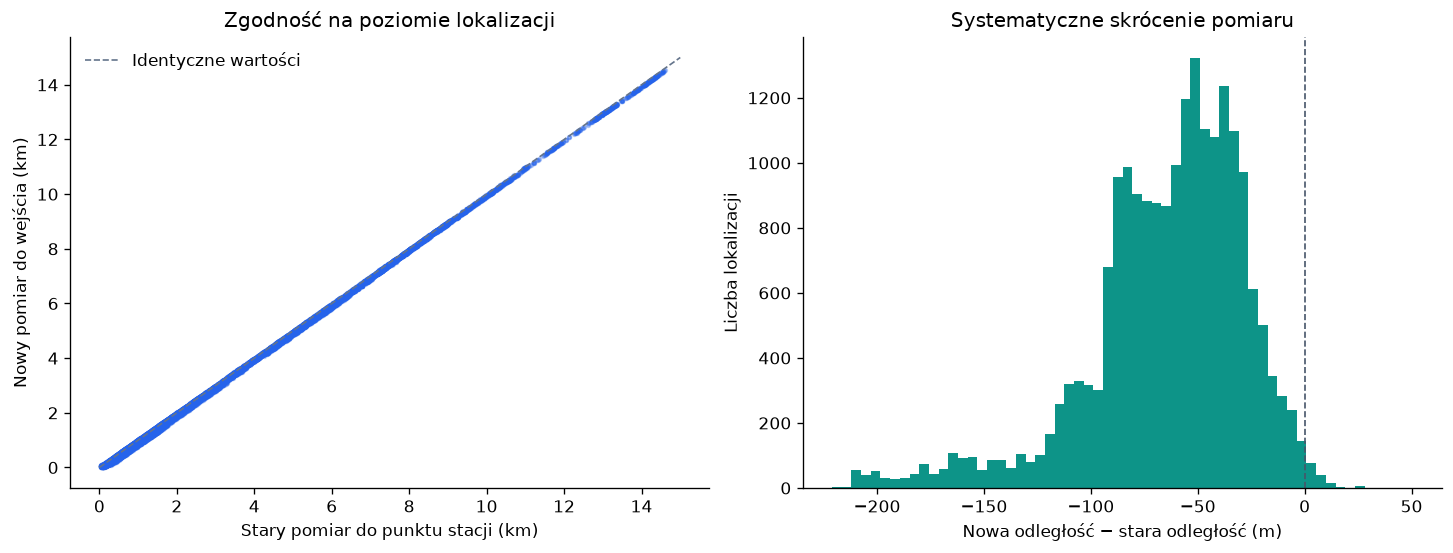

Eksport: dane/pochodne_bdot10k/porownanie_metro


In [4]:
plt.rcParams.update({'figure.dpi':120,'axes.spines.top':False,'axes.spines.right':False})
fig,axes=plt.subplots(1,2,figsize=(12,4.5),constrained_layout=True)
axes[0].scatter(unique.stara_odleglosc_m/1000,unique.nowa_odleglosc_m/1000,s=5,alpha=.3,color='#2563eb',rasterized=True)
limit=15
axes[0].plot([0,limit],[0,limit],'--',color='#64748b',linewidth=1,label='Identyczne wartości')
axes[0].set(xlabel='Stary pomiar do punktu stacji (km)',ylabel='Nowy pomiar do wejścia (km)',title='Zgodność na poziomie lokalizacji')
axes[0].legend(frameon=False)
axes[1].hist(unique.roznica_m,bins=60,color='#0d9488')
axes[1].axvline(0,color='#475569',linestyle='--',linewidth=1)
axes[1].set(xlabel='Nowa odległość − stara odległość (m)',ylabel='Liczba lokalizacji',title='Systematyczne skrócenie pomiaru')
fig.savefig(OUT/'porownanie_metro.png',dpi=170,bbox_inches='tight')
plt.show()
for frame,name in [(comparison,'porownanie_rekordy.csv'),(summary,'podsumowanie.csv'),
                   (station_summary.reset_index(),'porownanie_wedlug_starej_stacji.csv')]:
    frame.to_csv(OUT/name,index=False)
def sha256(path):
    h=hashlib.sha256()
    with path.open('rb') as f:
        for block in iter(lambda:f.read(1024*1024),b''):h.update(block)
    return h.hexdigest()
(OUT/'manifest.json').write_text(json.dumps({'wejscia':{str(p.relative_to(ROOT)):sha256(p) for p in [OLD,NEW,STATIONS]},
    'roznica':'nowa minus stara','promien_ziemi_m':6371008.8,'rekordy_sparowane':len(paired),
    'lokalizacje_sparowane':len(unique)},ensure_ascii=False,indent=2))
print('Eksport:',OUT.relative_to(ROOT))

## Wniosek

Nowa cecha jest zwykle krótsza, ponieważ punkty wejść rozciągają się wokół stacji. Wysoka zgodność i dokładne odtworzenie starszego algorytmu nie wskazują na problem z łączeniem wierszy ani jednostkami. Różnica pochodzi przede wszystkim ze zmiany definicji i źródła obiektu, a w mniejszym stopniu z metryki.

Do opisu dostępności metra **wejście jest bardziej bezpośrednim punktem odniesienia niż punkt stacji**, ale wciąż nie jest to rzeczywista droga dojścia. Nie można na podstawie tego porównania stwierdzić, że nowa cecha poprawi predykcję cen. Oba źródła wymagają również kontroli historycznej dostępności metra w dniu transakcji; źródła pochodzą z różnych eksportów. Braki dla punktów poza Warszawą wynikają z zasad kontroli zasięgu notebooka BDOT10k.